# Évaluation SOTA : IA & Preuve Formelle (sorc/qwen3.5-claude-4.6-opus + RAG + Agent)

**⚠️ AVANT DE COMMENCER :** Runtime → Change runtime type → **T4 GPU**.

### Version corrigée Colab
- **Modèle :** `sorc/qwen3.5-claude-4.6-opus`
- **Why3 installé via OPAM** (indisponible dans apt Colab)
- **Alt-Ergo** comme solveur SMT


In [7]:
# ============================================================
# 1. Installation APT + Python + OPAM + Why3 + Alt-Ergo + Ollama
# ============================================================
import os, sys, shutil, subprocess

def bash(cmd, check=True):
    print(f"$ {cmd}")
    return subprocess.run(cmd, shell=True, executable="/bin/bash", check=check, env=os.environ)

print("=" * 60)
print("STEP 1: APT packages")
print("=" * 60)
bash("apt-get update -qq")
bash("DEBIAN_FRONTEND=noninteractive apt-get install -y -qq software-properties-common")
bash("add-apt-repository -y universe || true", check=False)
bash("apt-get update -qq")
bash("DEBIAN_FRONTEND=noninteractive apt-get install -y -qq zstd curl pciutils lsof opam m4 bubblewrap unzip build-essential pkg-config libgmp-dev ca-certificates")
print("✅ APT packages installed.")

print("\n" + "=" * 60)
print("STEP 2: Python packages")
print("=" * 60)
bash("pip install -q --upgrade-strategy only-if-needed pysqlite3-binary langchain langchain-community langchain-huggingface langchain-text-splitters pymupdf pypdf chromadb pandas matplotlib seaborn sentence-transformers python-pptx unstructured")
print("✅ Python packages installed.")

# sqlite fix for Chroma
try:
    __import__("pysqlite3")
    sys.modules["sqlite3"] = sys.modules.pop("pysqlite3")
except Exception:
    pass

print("\n" + "=" * 60)
print("STEP 3: OPAM + Why3 + Alt-Ergo")
print("=" * 60)
if not os.path.exists("/root/.opam"):
    bash("opam init --disable-sandboxing -y")
else:
    print("OPAM already initialized.")

bash('bash -lc \'eval "$(opam env)" && opam update -y && opam install -y why3 alt-ergo\'')

# Symlink binaries
bash('bash -lc \'eval "$(opam env)" && ln -sf "$(which why3)" /usr/local/bin/why3\'')
bash('bash -lc \'eval "$(opam env)" && ln -sf "$(which alt-ergo)" /usr/local/bin/alt-ergo\'')

os.environ["PATH"] = "/root/.opam/default/bin:" + os.environ.get("PATH", "")

WHY3_BIN = "/usr/local/bin/why3"
bash(f"{WHY3_BIN} --version")
bash("alt-ergo --version")

# Detect provers
bash(f"{WHY3_BIN} config detect", check=False)

result = subprocess.run([WHY3_BIN, "config", "list-provers"], capture_output=True, text=True, env=os.environ)
print("\nDetected provers:")
print(result.stdout)

WHY3_PROVER = "alt-ergo"
print(f"✅ Why3 installed. Prover: {WHY3_PROVER}")

print("\n" + "=" * 60)
print("STEP 4: Ollama")
print("=" * 60)
os.environ["OLLAMA_SKIP_SYSTEMD"] = "1"
bash("curl -fsSL https://ollama.com/install.sh | sh")

OLLAMA_BIN = shutil.which("ollama") or "/usr/local/bin/ollama"
if not os.path.exists(OLLAMA_BIN):
    raise FileNotFoundError("❌ Ollama installation failed")

print(f"✅ Ollama installed at: {OLLAMA_BIN}")
bash(f"{OLLAMA_BIN} --version", check=False)

print("\n" + "=" * 60)
print("✅ CELL 1 COMPLETE")
print("=" * 60)


STEP 1: APT packages
$ apt-get update -qq
$ DEBIAN_FRONTEND=noninteractive apt-get install -y -qq software-properties-common
$ add-apt-repository -y universe || true
$ apt-get update -qq
$ DEBIAN_FRONTEND=noninteractive apt-get install -y -qq zstd curl pciutils lsof opam m4 bubblewrap unzip build-essential pkg-config libgmp-dev ca-certificates
✅ APT packages installed.

STEP 2: Python packages
$ pip install -q --upgrade-strategy only-if-needed pysqlite3-binary langchain langchain-community langchain-huggingface langchain-text-splitters pymupdf pypdf chromadb pandas matplotlib seaborn sentence-transformers python-pptx unstructured
✅ Python packages installed.

STEP 3: OPAM + Why3 + Alt-Ergo
OPAM already initialized.
$ bash -lc 'eval "$(opam env)" && opam update -y && opam install -y why3 alt-ergo'
$ bash -lc 'eval "$(opam env)" && ln -sf "$(which why3)" /usr/local/bin/why3'
$ bash -lc 'eval "$(opam env)" && ln -sf "$(which alt-ergo)" /usr/local/bin/alt-ergo'
$ /usr/local/bin/why3 --vers

In [8]:
# ============================================================
# 2. Start Ollama server & pull model
# ============================================================
import subprocess, time, os, requests, shutil

MODEL_NAME = "sorc/qwen3.5-claude-4.6-opus"
OLLAMA_URL = "http://127.0.0.1:11434/api/generate"
OLLAMA_BIN = shutil.which("ollama") or "/usr/local/bin/ollama"
WHY3_BIN = "/usr/local/bin/why3"
WHY3_PROVER = "alt-ergo"

# Kill old server
subprocess.run("pkill -f 'ollama serve'", shell=True, executable="/bin/bash", check=False)
time.sleep(2)

print("--- Starting Ollama server ---")
server_env = os.environ.copy()
server_env["OLLAMA_HOST"] = "127.0.0.1:11434"
server_env["OLLAMA_NUM_PARALLEL"] = "1"
server_env["OLLAMA_MAX_LOADED_MODELS"] = "1"

log_file = open("/tmp/ollama_server.log", "w")
ollama_proc = subprocess.Popen(
    [OLLAMA_BIN, "serve"],
    stdout=log_file,
    stderr=log_file,
    env=server_env
)
print(f"Server PID: {ollama_proc.pid}")

server_ready = False
for i in range(60):
    try:
        resp = requests.get("http://127.0.0.1:11434/api/tags", timeout=2)
        if resp.status_code == 200:
            server_ready = True
            print(f"✅ Ollama server ready! (took {i+1}s)")
            break
    except Exception:
        pass
    if ollama_proc.poll() is not None:
        print(f"❌ Ollama process died")
        break
    time.sleep(1)

if not server_ready:
    subprocess.run("cat /tmp/ollama_server.log", shell=True)
    raise RuntimeError("Ollama server did not start")

print(f"\n--- Pulling {MODEL_NAME} (may take several minutes) ---")
pull = subprocess.run([OLLAMA_BIN, "pull", MODEL_NAME], capture_output=True, text=True, timeout=3600)
print(pull.stdout[-2000:] if pull.stdout else "")
if pull.returncode != 0:
    print(pull.stderr)
    raise RuntimeError(f"Failed to pull model: {MODEL_NAME}")

print(f"✅ Model {MODEL_NAME} pulled.")

print("\n--- Smoke test ---")
try:
    warm_payload = {
        "model": MODEL_NAME,
        "prompt": "Reply only: OK",
        "stream": False,
        "keep_alive": "30m",
        "options": {"temperature": 0, "num_predict": 4, "num_ctx": 512}
    }
    test_resp = requests.post(OLLAMA_URL, json=warm_payload, timeout=300)
    test_resp.raise_for_status()
    print("✅ Smoke test:", test_resp.json().get("response", "")[:100])
except Exception as e:
    print(f"⚠️ Smoke test issue (may still work): {e}")

print(f"\n🎯 Active model: {MODEL_NAME}")
print(f"🎯 Why3 binary: {WHY3_BIN}")
print(f"🎯 Prover: {WHY3_PROVER}")


--- Starting Ollama server ---
Server PID: 36264
✅ Ollama server ready! (took 2s)

--- Pulling sorc/qwen3.5-claude-4.6-opus (may take several minutes) ---

✅ Model sorc/qwen3.5-claude-4.6-opus pulled.

--- Smoke test ---
✅ Smoke test: 

🎯 Active model: sorc/qwen3.5-claude-4.6-opus
🎯 Why3 binary: /usr/local/bin/why3
🎯 Prover: alt-ergo


In [9]:
# ============================================================
# 3. RAG : Base de Connaissances Expert
# ============================================================
from google.colab import files
from langchain_community.document_loaders import PyMuPDFLoader, TextLoader, UnstructuredPowerPointLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

print("Uploadez votre cours PDF/PPTX (ou Cancel pour cours par défaut) :\n")
try:
    uploaded = files.upload()
    pdf_files = list(uploaded.keys())
except Exception:
    pdf_files = []

if len(pdf_files) == 0:
    print("\nUtilisation du cours Why3 par défaut.")
    fallback = """
SYNTAXE WHY3 STRICTE :
module Test
  use int.Int
  use ref.Ref

  let fonction_exemple (x: int) : int
    requires { x >= 0 }
    ensures  { result = x + 1 }
  =
    x + 1
end

RÈGLES BOUCLES :
  let ref i = 0 in
  while i < n do
    invariant { 0 <= i <= n }
    variant { n - i }
    i <- i + 1
  done;

TUPLES :
  ensures { let (q, r) = result in a = b * q + r }

VARIABLES MUTABLES :
  let ref x = 0 in
  x <- x + 1;
  !x
"""
    with open("fallback_cours.txt", "w", encoding="utf-8") as f:
        f.write(fallback)
    pdf_files = ["fallback_cours.txt"]

docs = []
for fn in pdf_files:
    if fn.lower().endswith('.pdf'):
        loader = PyMuPDFLoader(fn)
    elif fn.lower().endswith('.pptx') or fn.lower().endswith('.ppt'):
        loader = UnstructuredPowerPointLoader(fn)
    else:
        loader = TextLoader(fn, encoding="utf-8")
    docs.extend(loader.load())

splitter = RecursiveCharacterTextSplitter(chunk_size=400, chunk_overlap=50)
splits = splitter.split_documents(docs)

embeddings = HuggingFaceEmbeddings(model_name="paraphrase-multilingual-MiniLM-L12-v2")
vectorstore = Chroma.from_documents(documents=splits, embedding=embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})
print("✅ RAG prêt.")


Uploadez votre cours PDF/PPTX (ou Cancel pour cours par défaut) :



Saving ctd1initRechVesontio4parPage.pdf to ctd1initRechVesontio4parPage (1).pdf
Saving ctd2initRechVesontio4parPage.pdf to ctd2initRechVesontio4parPage (1).pdf


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ RAG prêt.


In [10]:
# ============================================================
# 4. Moteur Agentic (Génération & Vérification)
# ============================================================
import re, requests, subprocess, os, shutil

MODEL_NAME = "sorc/qwen3.5-claude-4.6-opus"
OLLAMA_URL = "http://127.0.0.1:11434/api/generate"
WHY3_BIN = "/usr/local/bin/why3"
WHY3_PROVER = "alt-ergo"

VERIFY_ENV = os.environ.copy()
VERIFY_ENV["PATH"] = "/root/.opam/default/bin:" + VERIFY_ENV.get("PATH", "")

def extract_code_block(code_str):
    match = re.search(r'```(?:why3|mlw|ocaml)?\s*(.*?)```', code_str, re.DOTALL | re.IGNORECASE)
    return match.group(1).strip() if match else code_str.strip()

def normalize_why3_code(code_str):
    clean_code = extract_code_block(code_str)
    clean_code = clean_code.replace("\r\n", "\n").strip()

    lines = clean_code.split("\n")
    kept = []
    started = False
    for line in lines:
        s = line.strip().lower()
        if s.startswith("module ") or s.startswith("use ") or s.startswith("let "):
            started = True
        if started:
            kept.append(line)
    if kept:
        clean_code = "\n".join(kept).strip()

    if "module" not in clean_code.lower():
        clean_code = f"module Test\n  use int.Int\n  use ref.Ref\n\n{clean_code}\n\nend"

    if not clean_code.strip().lower().endswith("end"):
        clean_code = clean_code.rstrip() + "\nend"

    return clean_code

def verify_why3_code(code_str):
    clean_code = normalize_why3_code(code_str)

    if not os.path.exists(WHY3_BIN):
        return False, "", "why3 not found", clean_code

    with open("test_temp.mlw", "w", encoding="utf-8") as f:
        f.write(clean_code)

    try:
        res = subprocess.run(
            [WHY3_BIN, "prove", "-P", WHY3_PROVER, "test_temp.mlw"],
            capture_output=True,
            text=True,
            timeout=30,
            env=VERIFY_ENV,
        )
        out = res.stdout or ""
        err = res.stderr or ""
        is_valid = ("Valid" in out) and ("Unknown" not in out)
        return is_valid, out, err, clean_code
    except subprocess.TimeoutExpired:
        return False, "", "Timeout", clean_code
    except FileNotFoundError:
        return False, "", "why3 not found", clean_code

def is_infra_error(stderr_text, stdout_text=""):
    msg = ((stderr_text or "") + "\n" + (stdout_text or "")).lower()
    markers = ["why3 not found", "no such file", "unknown prover", "no prover", "not found"]
    return any(m in msg for m in markers)

def ollama_generate(prompt, temperature=0.0, timeout=420):
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "keep_alive": "30m",
        "options": {"temperature": temperature, "num_ctx": 2048, "num_predict": 512}
    }
    resp = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
    resp.raise_for_status()
    return resp.json().get("response", "")

def run_agentic_llm(prompt, use_rag=False, use_agentic_loop=False, max_retries=3):
    context = ""
    if use_rag:
        docs = retriever.invoke(prompt)
        context = "\n".join([d.page_content for d in docs])

    sys_prompt = (
        "Tu es un compilateur Why3 strict. Tu ne parles pas. "
        "Tu rédiges EXCLUSIVEMENT le code source MLW demandé, encadré par ```why3 et ```. "
        "Commence toujours par module Test. "
        "Utilise use int.Int et use ref.Ref. "
        "N'oublie jamais requires, ensures, invariant et variant."
    )

    if use_rag:
        full_prompt = f"{sys_prompt}\n\nCONTEXTE :\n{context}\n\nINSTRUCTION :\n{prompt}"
    else:
        full_prompt = f"{sys_prompt}\n\nINSTRUCTION :\n{prompt}"

    try:
        response = ollama_generate(full_prompt, temperature=0.0)
    except Exception as e:
        print(f"      ❌ LLM failed: {e}")
        return False, 1

    is_valid, stdout, stderr, clean_code = verify_why3_code(response)
    iterations = 1
    print(f"      [Itération 1] -> {'✅ Validé' if is_valid else '❌ Échec'}")
    if not is_valid:
        print(f"        {(stderr if stderr else stdout)[:200]}")

    if not is_valid and is_infra_error(stderr, stdout):
        print("      [Infra] Problème infrastructure. Arrêt.")
        return False, iterations

    if use_agentic_loop and not is_valid:
        for attempt in range(max_retries):
            print(f"      [Agent] Correction {attempt+1}/{max_retries}...")
            error_msg = stderr if stderr else stdout
            refine_prompt = (
                f"{sys_prompt}\n\n"
                f"Code échoué :\n```why3\n{clean_code}\n```\n\n"
                f"Erreur :\n{error_msg}\n\n"
                f"Corrige. Renvoie UNIQUEMENT le code dans ```why3 ... ```."
            )
            try:
                response = ollama_generate(refine_prompt, temperature=0.1)
            except Exception as e:
                iterations += 1
                print(f"      ❌ LLM failed: {e}")
                break

            is_valid, stdout, stderr, clean_code = verify_why3_code(response)
            iterations += 1
            print(f"      [Itération {iterations}] -> {'✅ Validé' if is_valid else '❌ Échec'}")
            if not is_valid:
                print(f"        {(stderr if stderr else stdout)[:200]}")

            if is_valid or is_infra_error(stderr, stdout):
                break

    return is_valid, iterations

print("✅ Moteur Agentic prêt.")
print(f"   Model: {MODEL_NAME}")
print(f"   Why3: {WHY3_BIN}")
print(f"   Prover: {WHY3_PROVER}")


✅ Moteur Agentic prêt.
   Model: sorc/qwen3.5-claude-4.6-opus
   Why3: /usr/local/bin/why3
   Prover: alt-ergo


In [11]:
# ============================================================
# 5. Lancement de la Campagne d'Évaluation
# ============================================================
import pandas as pd

# Preflight
assert os.path.exists(WHY3_BIN), f"Why3 missing: {WHY3_BIN}"
requests.get("http://127.0.0.1:11434/api/tags", timeout=5).raise_for_status()
print("✅ Preflight OK")
print(f"   Model: {MODEL_NAME}")
print(f"   Why3: {WHY3_BIN}")
print(f"   Prover: {WHY3_PROVER}")

test_cases = [
    {
        "level": 1,
        "name": "Dummy (Maximum)",
        "prompt": "Écris une fonction `let max (x y: int) : int` qui retourne le plus grand entier. Ajoute `requires { true }` et un `ensures` correct."
    },
    {
        "level": 2,
        "name": "Medium (Somme Itérative)",
        "prompt": "Écris une fonction `let sum_to_n (n: int) : int` utilisant une boucle while. Ajoute `requires { n >= 0 }` et `ensures { result >= 0 }`. Ajoute un invariant et un variant de terminaison."
    },
    {
        "level": 3,
        "name": "Hardcore (Div Euclidienne)",
        "prompt": "Écris `let div_euclidienne (a b: int) : (int, int)` par soustractions. requires a >= 0 et b > 0. L'invariant doit contenir a = b * q + r. N'oublie pas le variant."
    }
]

results = []

for tc in test_cases:
    print(f"\n{'='*50}\n>> TEST NIVEAU {tc['level']} : {tc['name']}\n{'='*50}")

    print("\n[1] BASELINE (LLM brut)")
    v, it = run_agentic_llm(tc['prompt'], use_rag=False, use_agentic_loop=False)
    results.append({"Niveau": tc['level'], "Test": tc['name'], "Méthode": "1. Baseline", "Succès": v, "Itérations": it})

    print("\n[2] RAG (Injection du Cours)")
    v, it = run_agentic_llm(tc['prompt'], use_rag=True, use_agentic_loop=False)
    results.append({"Niveau": tc['level'], "Test": tc['name'], "Méthode": "2. RAG", "Succès": v, "Itérations": it})

    print("\n[3] RAG + AGENTIC LOOP (Auto-correction)")
    v, it = run_agentic_llm(tc['prompt'], use_rag=True, use_agentic_loop=True)
    results.append({"Niveau": tc['level'], "Test": tc['name'], "Méthode": "3. Full Agent", "Succès": v, "Itérations": it})

df_results = pd.DataFrame(results)
print("\n✅ Évaluation terminée.")
display(df_results)


✅ Preflight OK
   Model: sorc/qwen3.5-claude-4.6-opus
   Why3: /usr/local/bin/why3
   Prover: alt-ergo

>> TEST NIVEAU 1 : Dummy (Maximum)

[1] BASELINE (LLM brut)
      [Itération 1] -> ✅ Validé

[2] RAG (Injection du Cours)
      [Itération 1] -> ✅ Validé

[3] RAG + AGENTIC LOOP (Auto-correction)
      [Itération 1] -> ✅ Validé

>> TEST NIVEAU 2 : Medium (Somme Itérative)

[1] BASELINE (LLM brut)
      [Itération 1] -> ❌ Échec
        

[2] RAG (Injection du Cours)
      [Itération 1] -> ❌ Échec
        

[3] RAG + AGENTIC LOOP (Auto-correction)
      [Itération 1] -> ❌ Échec
        
      [Agent] Correction 1/3...
      [Itération 2] -> ❌ Échec
        File "test_temp.mlw", line 8, characters 0-3: syntax error

      [Agent] Correction 2/3...
      [Itération 3] -> ❌ Échec
        File "test_temp.mlw", line 8, characters 15-17: syntax error

      [Agent] Correction 3/3...
      [Itération 4] -> ❌ Échec
        

>> TEST NIVEAU 3 : Hardcore (Div Euclidienne)

[1] BASELINE (LLM brut

,Niveau,Test,Méthode,Succès,Itérations
0,1,Dummy (Maximum),1. Baseline,True,1
1,1,Dummy (Maximum),2. RAG,True,1
2,1,Dummy (Maximum),3. Full Agent,True,1
3,2,Medium (Somme Itérative),1. Baseline,False,1
4,2,Medium (Somme Itérative),2. RAG,False,1
5,2,Medium (Somme Itérative),3. Full Agent,False,4
6,3,Hardcore (Div Euclidienne),1. Baseline,False,1
7,3,Hardcore (Div Euclidienne),2. RAG,False,1
8,3,Hardcore (Div Euclidienne),3. Full Agent,False,4


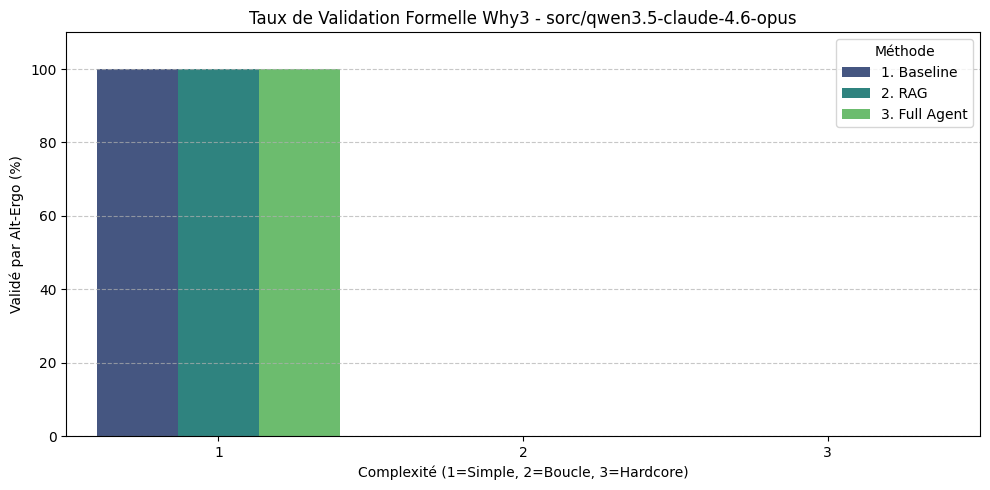


Tableau des Itérations :


,Niveau,Test,Méthode,Succès,Itérations
0,1,Dummy (Maximum),1. Baseline,True,1
1,1,Dummy (Maximum),2. RAG,True,1
2,1,Dummy (Maximum),3. Full Agent,True,1
3,2,Medium (Somme Itérative),1. Baseline,False,1
4,2,Medium (Somme Itérative),2. RAG,False,1
5,2,Medium (Somme Itérative),3. Full Agent,False,4
6,3,Hardcore (Div Euclidienne),1. Baseline,False,1
7,3,Hardcore (Div Euclidienne),2. RAG,False,1
8,3,Hardcore (Div Euclidienne),3. Full Agent,False,4


In [12]:
# ============================================================
# 6. Résultats & Graphique
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

df_results["Succès (%)"] = df_results["Succès"].astype(int) * 100

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x="Niveau", y="Succès (%)", hue="Méthode", palette="viridis")
plt.title(f"Taux de Validation Formelle Why3 - {MODEL_NAME}")
plt.xlabel("Complexité (1=Simple, 2=Boucle, 3=Hardcore)")
plt.ylabel("Validé par Alt-Ergo (%)")
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Méthode")
plt.tight_layout()
plt.show()

print("\nTableau des Itérations :")
display(df_results[["Niveau", "Test", "Méthode", "Succès", "Itérations"]])
